In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.datasets import make_circles

1. В первом задании поэкспериментируйте с различными значениями аргумента C класса SVC. Сделайте вывод о том, как он влияет на модель классификации.

In [ ]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

In [ ]:
def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0],model.support_vectors_[:, 1], linewidth=7, facecolors='green')

    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

    X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])
    X1 = np.linspace(X[:, 1].min(),X[:, 1].max(), X.shape[0])

    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.contourf(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], alpha=0.5)

    plt.title("Диаграмма рассеяния c линией разделения и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.show()

Диаграмма с C=0.1


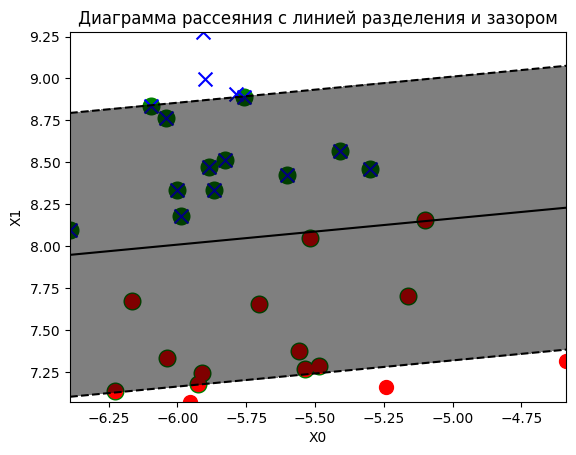

Диаграмма с C=1


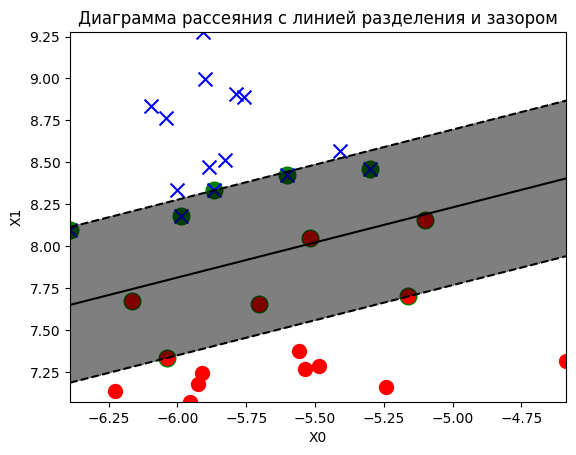

Диаграмма с C=10


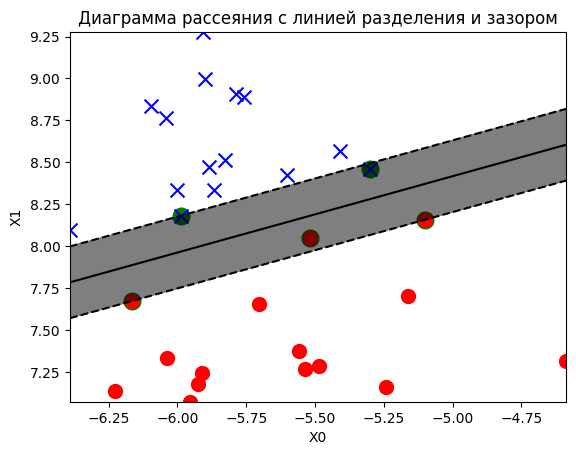

Диаграмма с C=100


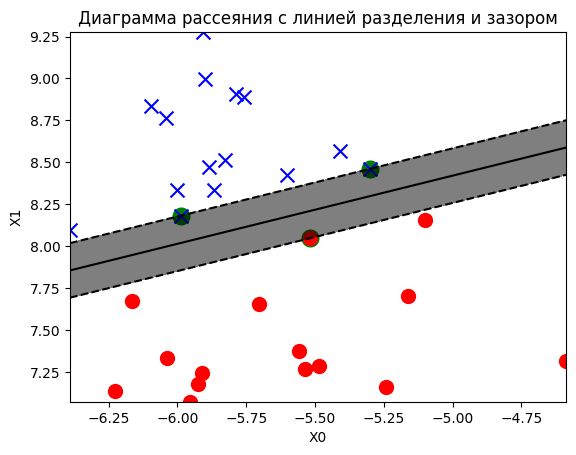

Диаграмма с C=1000


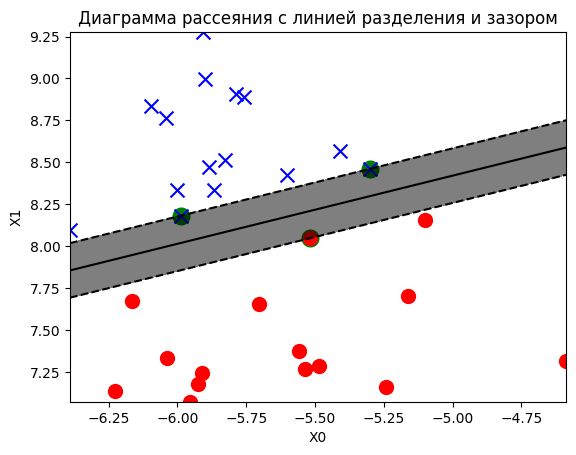

In [ ]:
C = [0.1, 1, 10, 100, 1000]

def plot_svm_with_C(X, y, C):
    svm_linear = SVC(kernel='linear', C=C)
    svm_linear.fit(X, y)
    print(f"Диаграмма с C={C}")
    plot_decision_regions(X, y, svm_linear)


for i in C:
    plot_svm_with_C(X, y, i)


2. В первом задании подвигайте точку нового предсказания. Убедитесь, что с другой стороны границы предсказывается другой класс. Как изменяется предсказание, если точка ляжет внутрь полосы зазора?

In [ ]:
svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X, y)

SVC(C=100, kernel='linear')

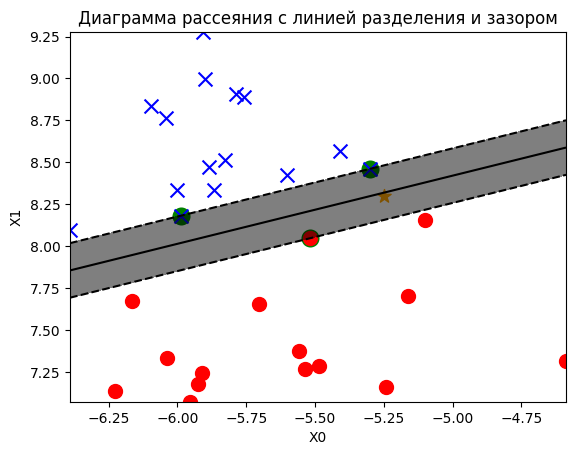

[-0.11385246]


array([0])

In [ ]:
observation_new = [[-5.25, 8.3]]
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=100, color='orange')
plot_decision_regions(X, y, svm_linear)
print(svm_linear.decision_function(observation_new))
svm_linear.predict(observation_new)

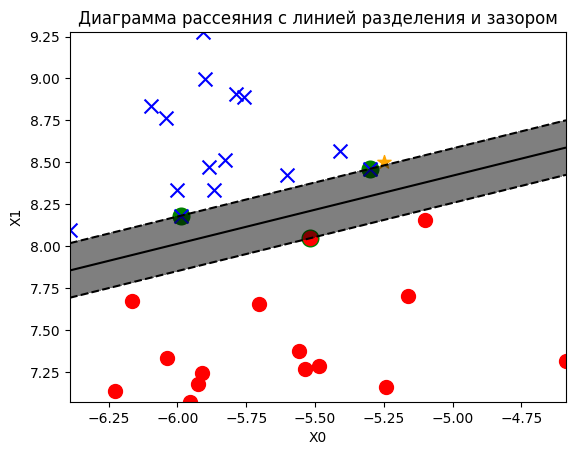

[1.11551392]


array([1])

In [ ]:
observation_new = [[-5.25, 8.5]]
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=100, color='orange')
plot_decision_regions(X, y, svm_linear)
print(svm_linear.decision_function(observation_new))
svm_linear.predict(observation_new)

3. Во втором задании повторите анализ с методом опорных векторов с другими видами ядер. Сравните вид границы принятия решения и показатели точности модели.

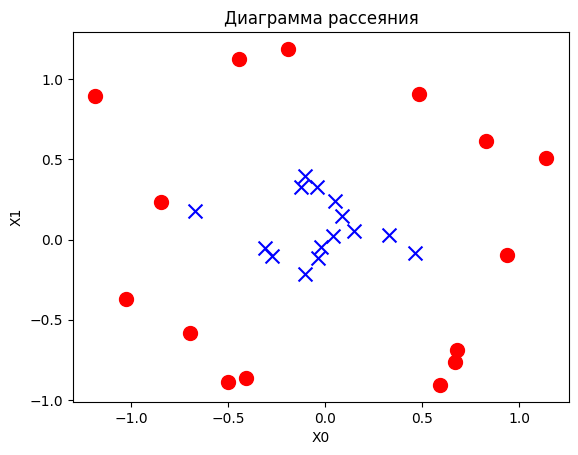

In [ ]:
X, y = make_circles(n_samples=30, random_state=5, factor=.1, noise=.2)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

Диаграмма с ядром linear


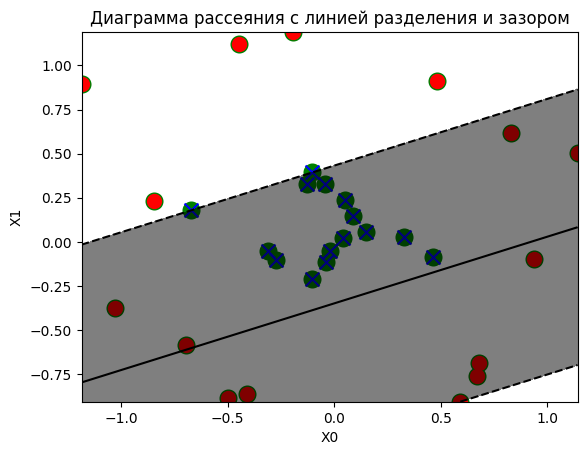

Точность модели с ядром linear:  0.7
Матрица ошибок для ядра linear:
 [[ 6  9]
 [ 0 15]]
Диаграмма с ядром poly


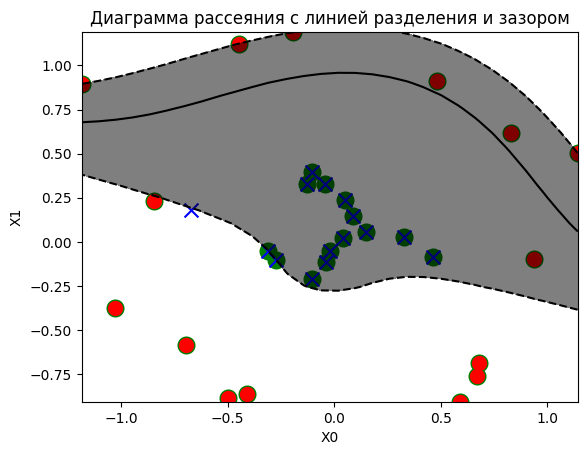

Точность модели с ядром poly:  0.7
Матрица ошибок для ядра poly:
 [[ 6  9]
 [ 0 15]]
Диаграмма с ядром rbf


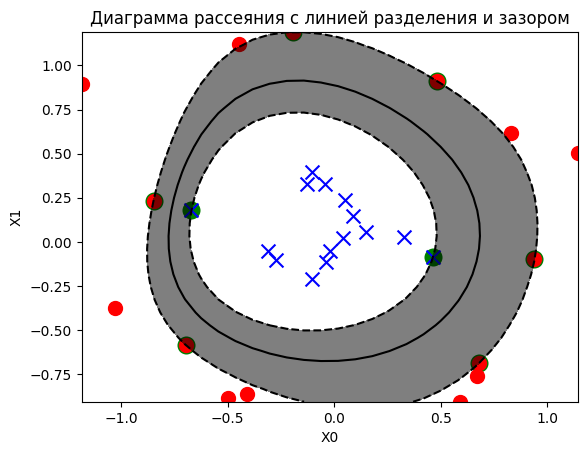

Точность модели с ядром rbf:  1.0
Матрица ошибок для ядра rbf:
 [[15  0]
 [ 0 15]]


In [ ]:
def plot_svm_with_kernel(X, y, kernel_type, C_value=100):
    svm = SVC(kernel=kernel_type, C=C_value)
    svm.fit(X, y)
    print(f"Диаграмма с ядром {kernel_type}")
    plot_decision_regions(X, y, svm)

    y_pred = svm.predict(X)
    print(f"Точность модели с ядром {kernel_type}: ", metrics.accuracy_score(y, y_pred))
    print(f"Матрица ошибок для ядра {kernel_type}:\n", metrics.confusion_matrix(y, y_pred))
    return svm

kernels = ['linear', 'poly', 'rbf']  # Линейное, полиномиальное, RBF ядро
for kernel in kernels:
    plot_svm_with_kernel(X, y, kernel)


4. В третьем задании поэкспериментируйте со значением аргумента C. Сделайте вывод о том, как он влияет на модель.

In [ ]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

Диаграмма с полиномиальным ядром и C=0.1


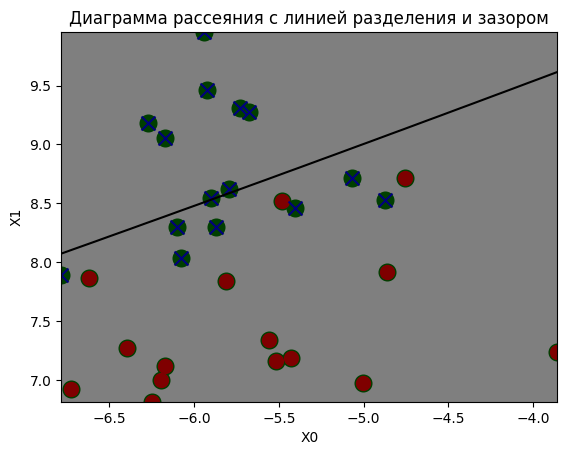

Точность модели с C=0.1:  0.7666666666666667
Матрица ошибок для C=0.1:
 [[15  0]
 [ 7  8]]
Диаграмма с полиномиальным ядром и C=1


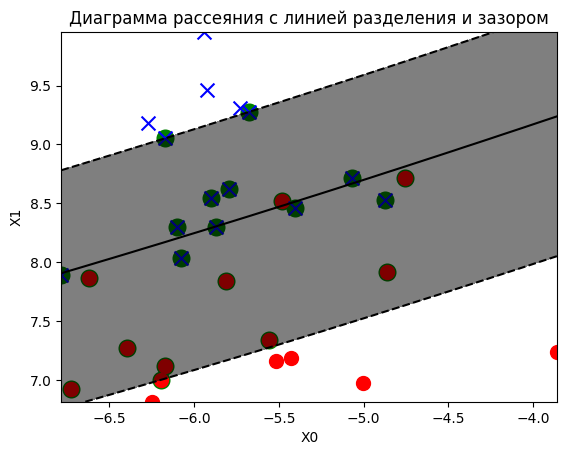

Точность модели с C=1:  0.8
Матрица ошибок для C=1:
 [[14  1]
 [ 5 10]]
Диаграмма с полиномиальным ядром и C=2


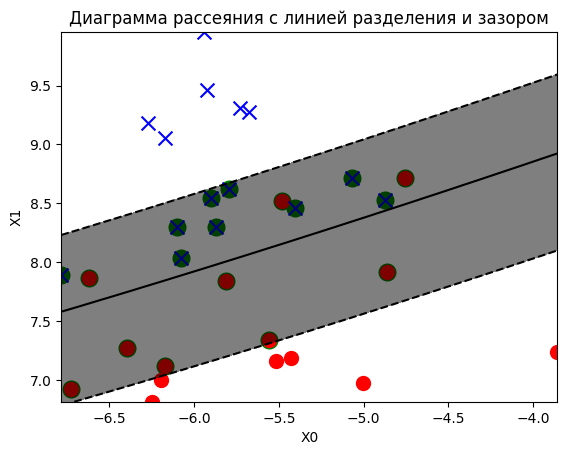

Точность модели с C=2:  0.9
Матрица ошибок для C=2:
 [[12  3]
 [ 0 15]]
Диаграмма с полиномиальным ядром и C=10


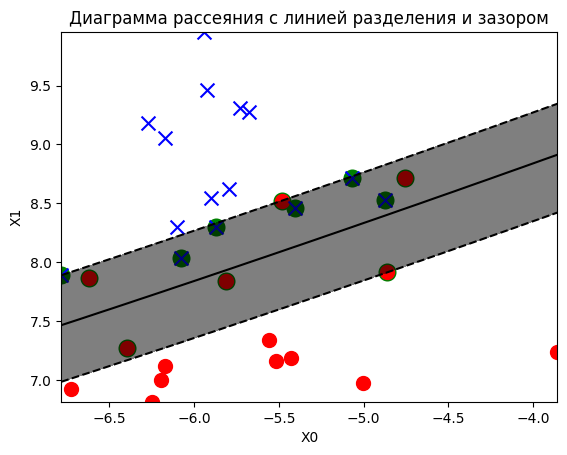

Точность модели с C=10:  0.9
Матрица ошибок для C=10:
 [[12  3]
 [ 0 15]]
Диаграмма с полиномиальным ядром и C=100


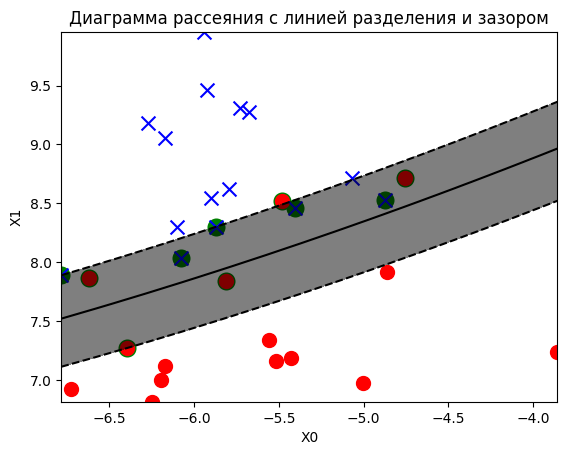

Точность модели с C=100:  0.9
Матрица ошибок для C=100:
 [[12  3]
 [ 0 15]]


In [ ]:
C_values = [0.1, 1, 2, 10, 100]
def plot_svm_with_C_poly(X, y, C_value, degree=4):
    svm_poly = SVC(kernel='poly', degree=degree, C=C_value)
    svm_poly.fit(X, y)
    print(f"Диаграмма с полиномиальным ядром и C={C_value}")
    plot_decision_regions(X, y, svm_poly)

    y_pred = svm_poly.predict(X)
    print(f"Точность модели с C={C_value}: ", metrics.accuracy_score(y, y_pred))
    print(f"Матрица ошибок для C={C_value}:\n", metrics.confusion_matrix(y, y_pred))

for C_value in C_values:
    plot_svm_with_C_poly(X, y, C_value)


5. В третьем задании примените классификатор без ядра. Познакомьтесь и примените класс Linear_SVC.

In [ ]:
def plot_decision_regions(X, y, model):
    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
    X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)
    X1 = np.linspace(X[:, 1].min(), X[:, 1].max(), 500)

    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)

    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])

    plt.title("Диаграмма рассеяния с границей раздела и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.show()

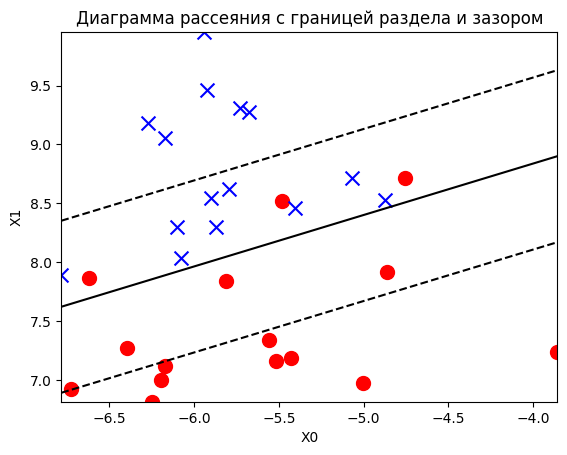

Точность модели LinearSVC:  0.9
Матрица ошибок для LinearSVC:
 [[12  3]
 [ 0 15]]


In [ ]:
from sklearn.svm import LinearSVC

svm_linear = LinearSVC(C=100)
svm_linear.fit(X, y)

plot_decision_regions(X, y, svm_linear)


y_pred_linear = svm_linear.predict(X)
print(f"Точность модели LinearSVC: ", metrics.accuracy_score(y, y_pred_linear))
print(f"Матрица ошибок для LinearSVC:\n", metrics.confusion_matrix(y, y_pred_linear))


6. Сгенерируйте датасет для классификации из 1000 точек и 5 атрибутов. Попробуйте применить метод опорных векторов на нем. Найдите методом подбора наилучшее ядро и значение С.

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

In [ ]:
X, y = make_classification(n_samples=1000, n_features=5, n_classes=2, random_state=42, n_informative=3, n_redundant=2)
# Разделение данных на тренировочную и тестовую выборку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'degree': [3, 4]
}

svm = SVC()

# Применение GridSearch для поиска лучших гиперпараметров
grid_search = GridSearchCV(svm, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_}")

y_pred = grid_search.predict(X_test)
print(f"Точность на тестовых данных: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Матрица ошибок:\n {metrics.confusion_matrix(y_test, y_pred)}")


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Лучшие параметры: {'C': 100, 'degree': 3, 'kernel': 'rbf'}
Лучшая точность на кросс-валидации: 0.95
Точность на тестовых данных: 0.96
Матрица ошибок:
 [[ 87   7]
 [  1 105]]


7. Попробуйте данную модель с большим количеством точек. На каком количестве обучение начинает занимать существенное время?

In [ ]:
import time

In [ ]:
def measure_training_time(n_samples):
    X_large, y_large = make_classification(n_samples=n_samples, n_features=5, n_classes=2, random_state=42, n_informative=3, n_redundant=2)
    X_train, X_test, y_train, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)

    start_time = time.time()
    grid_search.fit(X_train, y_train)
    end_time = time.time()

    training_time = end_time - start_time
    print(f"Время обучения на {n_samples} точках: {training_time:.2f} секунд")
    return training_time


sample_sizes = [100, 200, 500, 1000, 5000, 10000]
training_times = []

for size in sample_sizes:
    training_times.append(measure_training_time(size))


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Время обучения на 100 точках: 0.60 секунд
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Время обучения на 200 точках: 1.83 секунд
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Время обучения на 500 точках: 2.33 секунд
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Время обучения на 1000 точках: 4.64 секунд
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Время обучения на 5000 точках: 69.46 секунд
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Время обучения на 10000 точках: 324.20 секунд


8. Примените метод опорных векторов для задачи множественной классификации. Самостоятельно сгенерируйте визуализируемый датасет для этой задачи. Поробуйте изобразить границу принятия решений и зазор.

In [ ]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

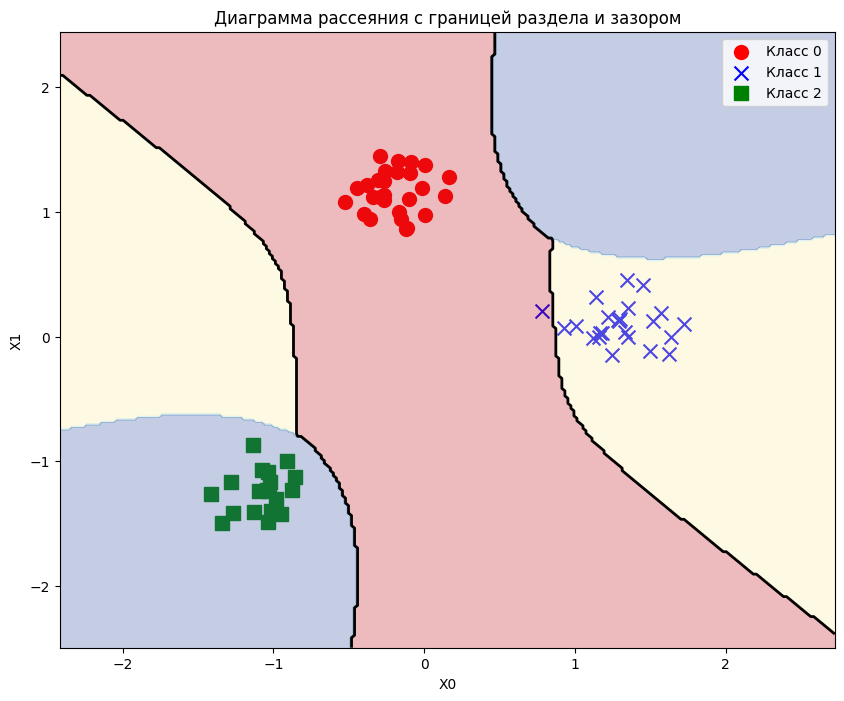

Confusion Matrix:
[[ 7  0  0]
 [ 0  9  0]
 [ 0  0 14]]
Accuracy Score: 1.0
Количество поддерживающих векторов для каждого класса: [7 8 3]


In [ ]:
def plot_decision_regions(X, y, model):
    # Плотим данные разных классов
    markers = ['o', 'x', 's']
    colors = ['r', 'b', 'g']
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(X[y == cl, 0], X[y == cl, 1], marker=markers[idx], color=colors[idx], label=f'Класс {cl}', s=100)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.02  # разрешение сетки
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])  # предсказание модели
    Z = Z.reshape(xx.shape)  # преобразуем в ту же форму, что и сетка

    # Плотим границы принятия решений
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.contour(xx, yy, Z, levels=[-0.5, 0.5], linewidths=2, colors='k')

    plt.title("Диаграмма рассеяния с границей раздела и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.legend(loc='best')

X, y = datasets.make_blobs(n_samples=100, centers=3, n_features=2, random_state=42, cluster_std=1.0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

svm_poly = SVC(kernel='poly', degree=4, C=2)
svm_poly.fit(X_train, y_train)

plt.figure(figsize=(10, 8))
plot_decision_regions(X_train, y_train, svm_poly)
plt.show()


y_pred = svm_poly.predict(X_test)
print(f'Confusion Matrix:\n{metrics.confusion_matrix(y_test, y_pred)}')
print(f'Accuracy Score: {metrics.accuracy_score(y_test, y_pred)}')

print(f'Количество поддерживающих векторов для каждого класса: {svm_poly.n_support_}')




9. Выберите из библиотеки sklearn готовый датасет для классификации и попробуйте смоделировать его при помощи метода опорных векторов.

In [ ]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

svm_model = SVC(kernel='linear', C = 100)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

# Оцениваем точность модели
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')


Accuracy: 1.0000


Повторите такой же анализ для задачи регрессии и соответствующего датасета.

In [ ]:
# Импортируем необходимые библиотеки
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import numpy as np

# Загружаем датасет California Housing
california = datasets.fetch_california_housing()
X = california.data  # Признаки
y = california.target  # Целевая переменная (цены на жилье)

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Создаем и обучаем модель SVR с ядром радиальной базисной функции
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

# Делаем прогноз на тестовых данных
y_pred = svr_model.predict(X_test)

# Оцениваем модель с помощью средней квадратичной ошибки (MSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Корень из MSE (RMSE)
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')


Root Mean Squared Error (RMSE): 1.1615
